Gini impurity measures how pure is a data set, that is how well does it fit into a single characterization. The closer to zero its Gini impurity is, the closer it is to belong to only one class.

You calculate the Gini impurity as the sum of the products of the probability of belonging to one class by the probability of not belonging to that class. When one set contains all data points for a class, the probability of not belonging to that class goes to 0 and the corresponding product goes to 0 too, giving a Gini impurity of 0, making the set pure.

This is used to evaluate how well a decision node splits data into its leaf nodes. Calculate the Gini impurity of each leaf node; the closer they are to zero, the better a decision is to split the data. A Gini impurity of 0 means that the decision perfectly separates the classes. When a feature is binary, there is only one decision to evaluate. When a feature is multiclass, you have various combinations of decisions to evaluate: belonging to a class versus belonging to any of the others and also belonging to a set of classes versus belonging to any of the others. When a feature is continuous, your possible decissions are the cut number (is the value lower or greater than the cut number)

You can then use Gini impurity to select the best decision to place in the root node of a tree: the one that generates the leafs with the lowest Gini impurity. Either belonging to a class or set of classes for a categorical feature, or the cut value for a continuous feature. Then you can use it again at each of those leaf nodes to select the decision for each.

Additionally, you can use Gini impurity to prevent overfitting. Giving a best decision already selected for a node level, you can chose to not make a decision and leave the node as a leaf node if the decision does not get a big enough decrease in impurity, in the way that it doesn't pay to separate data if tha decision does not purify enough the outcome. You can also limit the depth of a decision tree to prevent overfitting.

# what is Gini impurity

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../../jupyter_notebooks/DATA/penguins_size.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
df['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [5]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
# There are very few rows with NA, we'll just drop them.

df=df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


In [9]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [10]:
df['sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [11]:
df[df['sex']=='.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


So there is only one row with that weird value for sex. We can try to guess the sex of the specimen based on its dimensions, specially the body_mass_g

In [12]:
df[df['species']=='Gentoo'].groupby('sex').describe().transpose()

sex                           .       FEMALE         MALE
culmen_length_mm  count     1.0    58.000000    61.000000
                  mean     44.5    45.563793    49.473770
                  std       NaN     2.051247     2.720594
                  min      44.5    40.900000    44.400000
                  25%      44.5    43.850000    48.100000
                  50%      44.5    45.500000    49.500000
                  75%      44.5    46.875000    50.500000
                  max      44.5    50.500000    59.600000
culmen_depth_mm   count     1.0    58.000000    61.000000
                  mean     15.7    14.237931    15.718033
                  std       NaN     0.540249     0.741060
                  min      15.7    13.100000    14.100000
                  25%      15.7    13.800000    15.200000
                  50%      15.7    14.250000    15.700000
                  75%      15.7    14.600000    16.100000
                  max      15.7    15.500000    17.300000
flipper_length_mm count     1.0    58.000000    61.000000
                  mean    217.0   212.706897   221.540984
                  std       NaN     3.897856     5.673252
                  min     217.0   203.000000   208.000000
                  25%     217.0   210.000000   218.000000
                  50%     217.0   212.000000   221.000000
                  75%     217.0   215.000000   225.000000
                  max     217.0   222.000000   231.000000
body_mass_g       count     1.0    58.000000    61.000000
                  mean   4875.0  4679.741379  5484.836066
                  std       NaN   281.578294   313.158596
                  min    4875.0  3950.000000  4750.000000
                  25%    4875.0  4462.500000  5300.000000
                  50%    4875.0  4700.000000  5500.000000
                  75%    4875.0  4875.000000  5700.000000
                  max    4875.0  5200.000000  6300.000000

Looking at the data, it is not 100% conclusive, but it coincides more with the data of a female. Let's change that '.' value.

In [13]:
df.at[336,'sex'] = 'FEMALE'

Let's see the separation of the different species by feature.

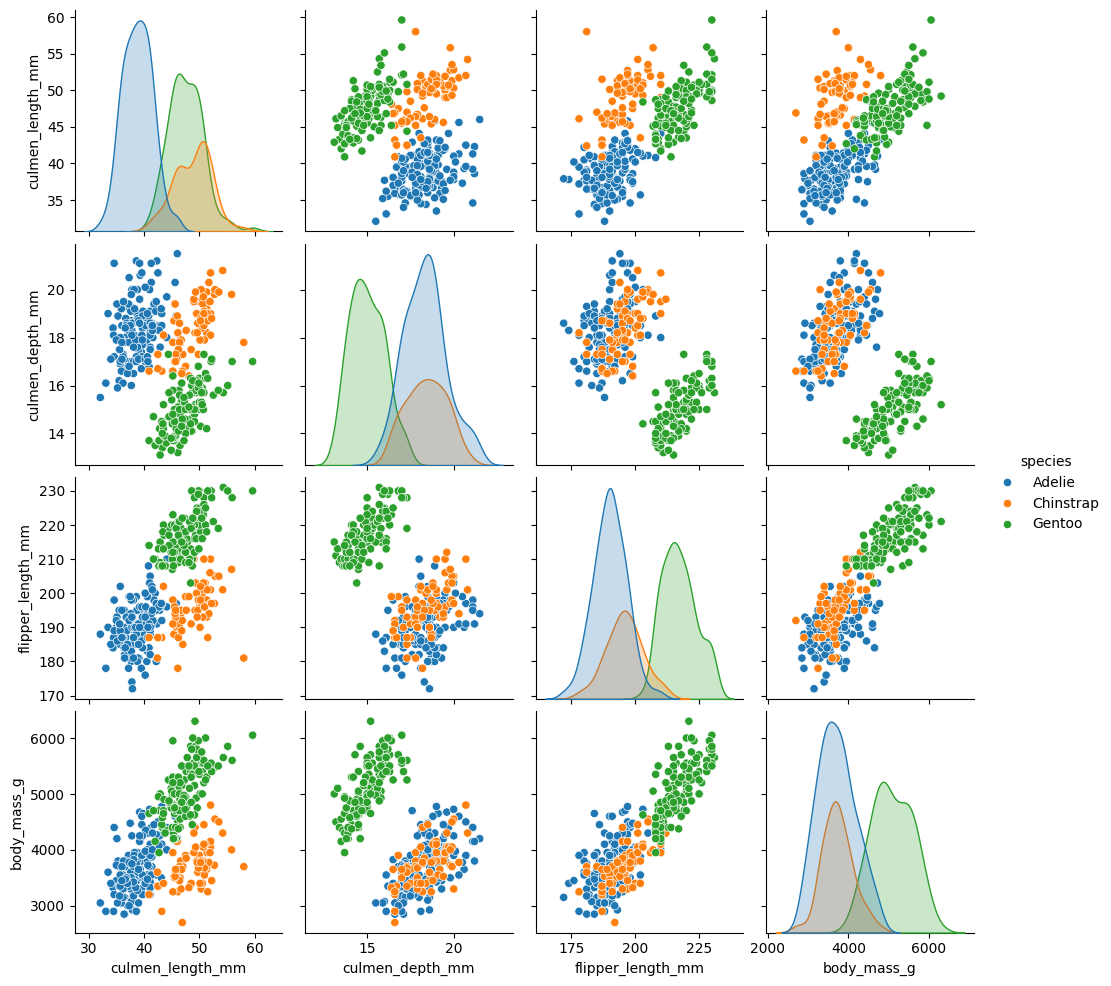

In [14]:
sns.pairplot(df,hue='species')

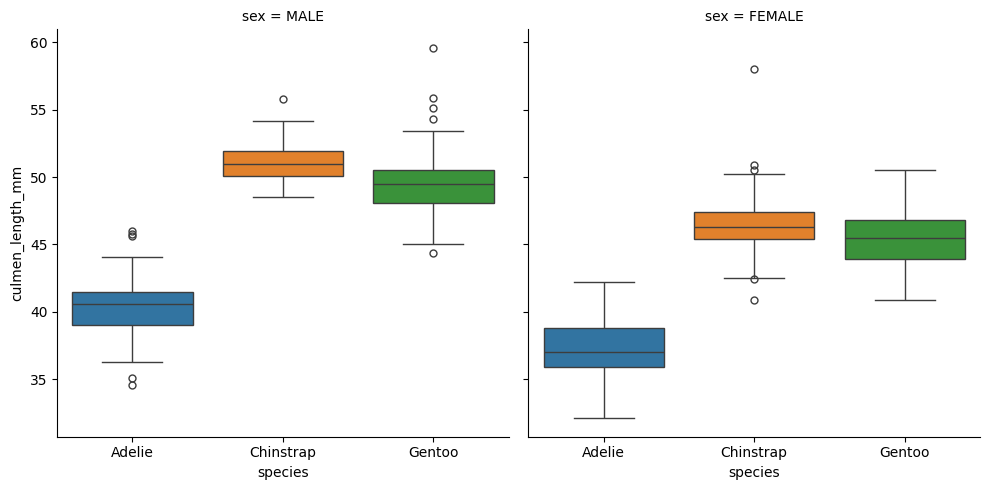

In [15]:
sns.catplot(x='species',y='culmen_length_mm',data=df,kind='box',col='sex',hue='species') 

In [16]:
pd.get_dummies(df.drop('species',axis=1),drop_first=True,dtype=int)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,0,1,1
1,39.5,17.4,186.0,3800.0,0,1,0
2,40.3,18.0,195.0,3250.0,0,1,0
4,36.7,19.3,193.0,3450.0,0,1,0
5,39.3,20.6,190.0,3650.0,0,1,1
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,0,0,0
340,46.8,14.3,215.0,4850.0,0,0,0
341,50.4,15.7,222.0,5750.0,0,0,1
342,45.2,14.8,212.0,5200.0,0,0,0


This is what we want, so let's separate the features and labels like this.

In [17]:
X= pd.get_dummies(df.drop('species',axis=1),drop_first=True,dtype=int)
y=df['species']

We can skip the scaling, since for a decision tree we are going to be making the decision by comparing features with values directly, so it doesn't matter if they are not scaled the same.

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
model=DecisionTreeClassifier()

In [22]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
base_preds=model.predict(X_test)
base_preds

array(['Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Chinstrap', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap', 'Chinstrap',
       'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie',
       'Adelie', 'Gentoo', 'Chinstrap', 'Chinstrap', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Gentoo', 'Adelie'

In [26]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [27]:
print(classification_report(y_test,base_preds))

              precision    recall  f1-score   support

      Adelie       0.95      1.00      0.98        41
   Chinstrap       1.00      0.91      0.95        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.98       101
   macro avg       0.98      0.97      0.98       101
weighted avg       0.98      0.98      0.98       101



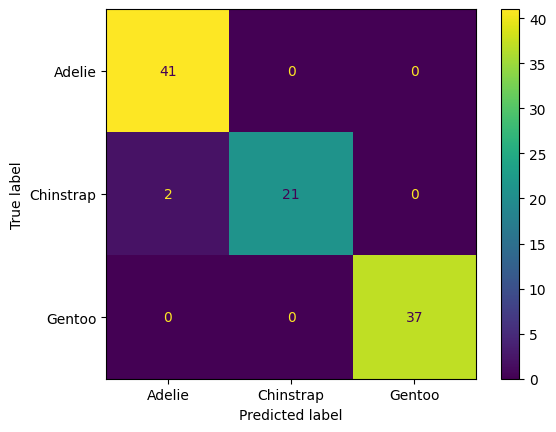

In [30]:
ConfusionMatrixDisplay.from_estimator(model, X_test,y_test)

## Decision tree data

The decision tree is a human friendly model, since it contains ideas and data directly interpretable, without much effort.

Let's build up a dataframe representing the tree.

In [31]:
model.feature_importances_

array([0.33609286, 0.04203954, 0.542054  , 0.        , 0.0681854 ,
       0.        , 0.0116282 ])

In [32]:
X.columns

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_MALE'],
      dtype='object')

In [34]:
pd.DataFrame(index=X.columns,data=model.feature_importances_,columns=['Feature Importance']).sort_values("Feature Importance")

,Feature Importance
body_mass_g,0.000000
island_Torgersen,0.000000
sex_MALE,0.011628
culmen_depth_mm,0.042040
island_Dream,0.068185
culmen_length_mm,0.336093
flipper_length_mm,0.542054


In [35]:
from sklearn.tree import plot_tree

[Text(0.5, 0.9166666666666666, 'x[2] <= 206.5\ngini = 0.633\nsamples = 233\nvalue = [105, 45, 83]'),
 Text(0.2727272727272727, 0.75, 'x[0] <= 42.35\ngini = 0.418\nsamples = 147\nvalue = [104, 42, 1]'),
 Text(0.38636363636363635, 0.8333333333333333, 'True  '),
 Text(0.18181818181818182, 0.5833333333333334, 'gini = 0.0\nsamples = 97\nvalue = [97, 0, 0]'),
 Text(0.36363636363636365, 0.5833333333333334, 'x[4] <= 0.5\ngini = 0.274\nsamples = 50\nvalue = [7.0, 42.0, 1.0]'),
 Text(0.18181818181818182, 0.4166666666666667, 'x[6] <= 0.5\ngini = 0.245\nsamples = 7\nvalue = [6, 0, 1]'),
 Text(0.09090909090909091, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.2727272727272727, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [6, 0, 0]'),
 Text(0.5454545454545454, 0.4166666666666667, 'x[0] <= 44.2\ngini = 0.045\nsamples = 43\nvalue = [1, 42, 0]'),
 Text(0.45454545454545453, 0.25, 'x[2] <= 189.5\ngini = 0.32\nsamples = 5\nvalue = [1, 4, 0]'),
 Text(0.36363636363636365, 0.08333333333333333, 'gin

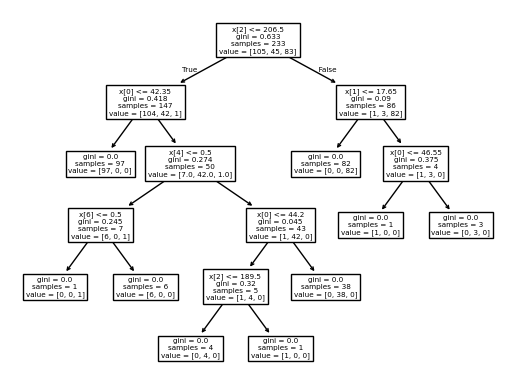

In [36]:
plot_tree(model)

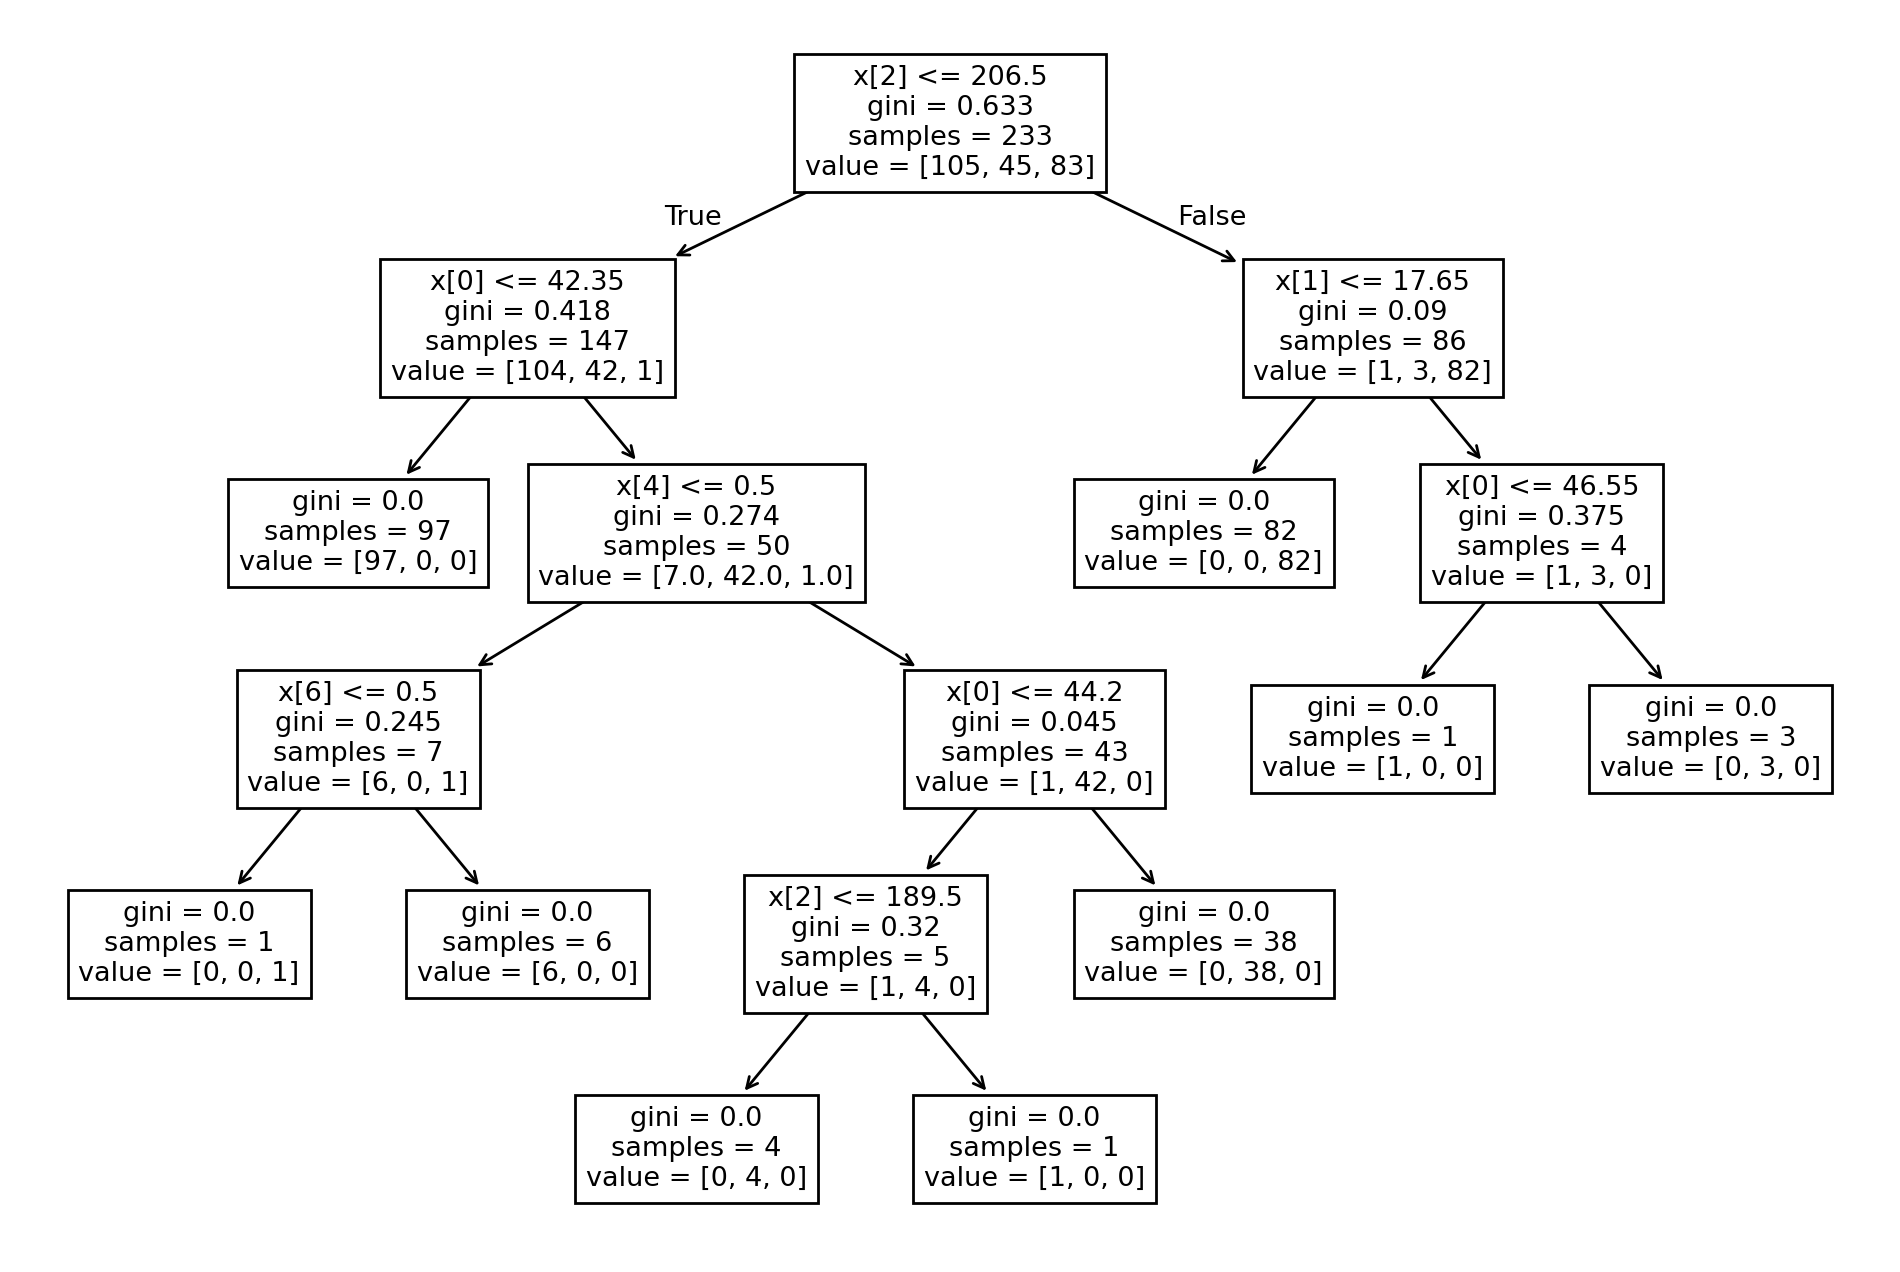

In [38]:
plt.figure(figsize=(12,8),dpi=200)
plot_tree(model);

Let's make it more readable

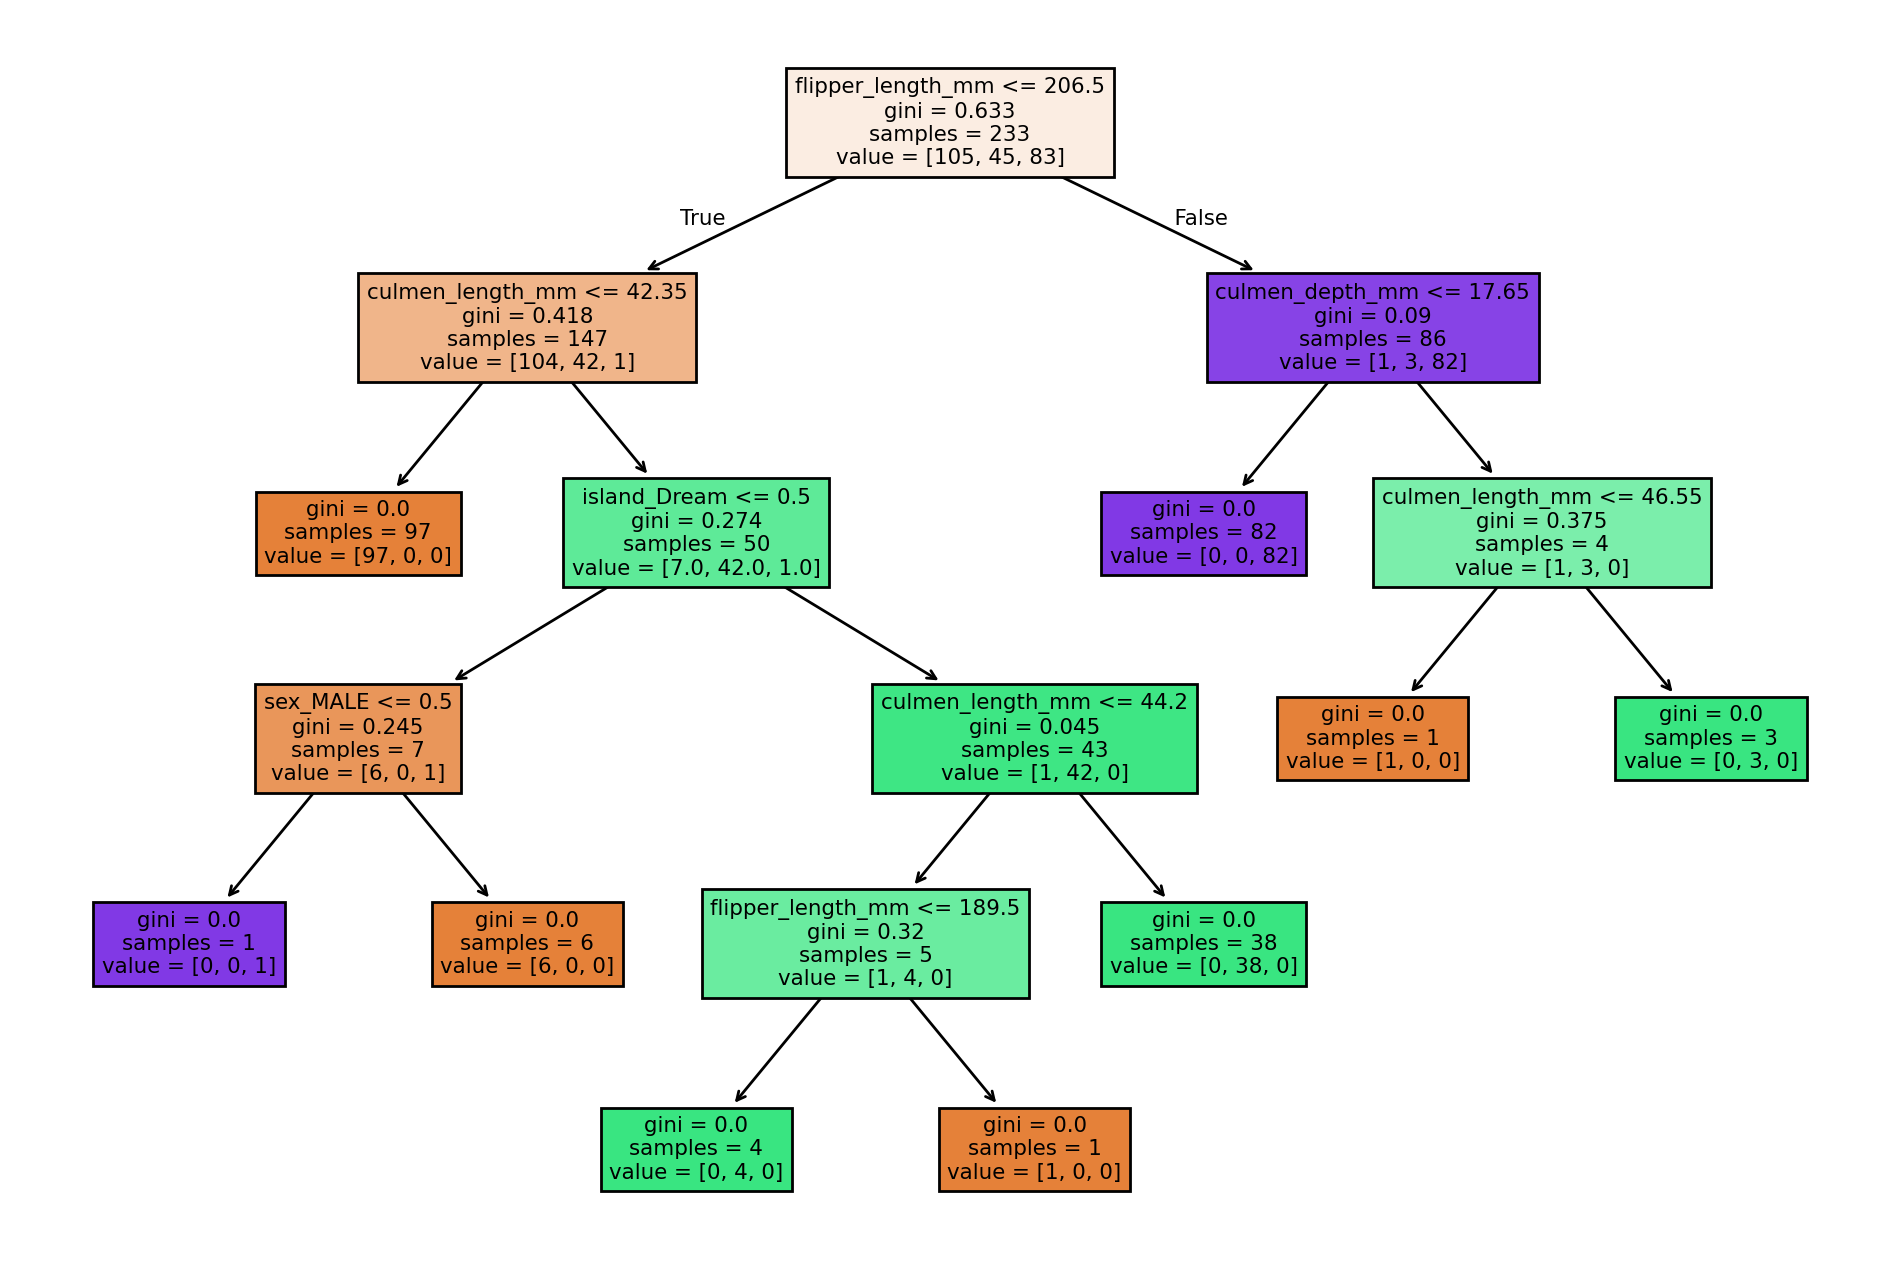

In [39]:
plt.figure(figsize=(12,8),dpi=200)
plot_tree(model,feature_names=X.columns,filled=True);

In [44]:
def report_model(model):
    model_preds=model.predict(X_test)
    print(classification_report(y_test,model_preds))
    print('\n')
    plt.figure(figsize=(12,8),dpi=200)
    plot_tree(model,feature_names=X.columns,filled=True);

              precision    recall  f1-score   support

      Adelie       0.95      1.00      0.98        41
   Chinstrap       1.00      0.91      0.95        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.98       101
   macro avg       0.98      0.97      0.98       101
weighted avg       0.98      0.98      0.98       101





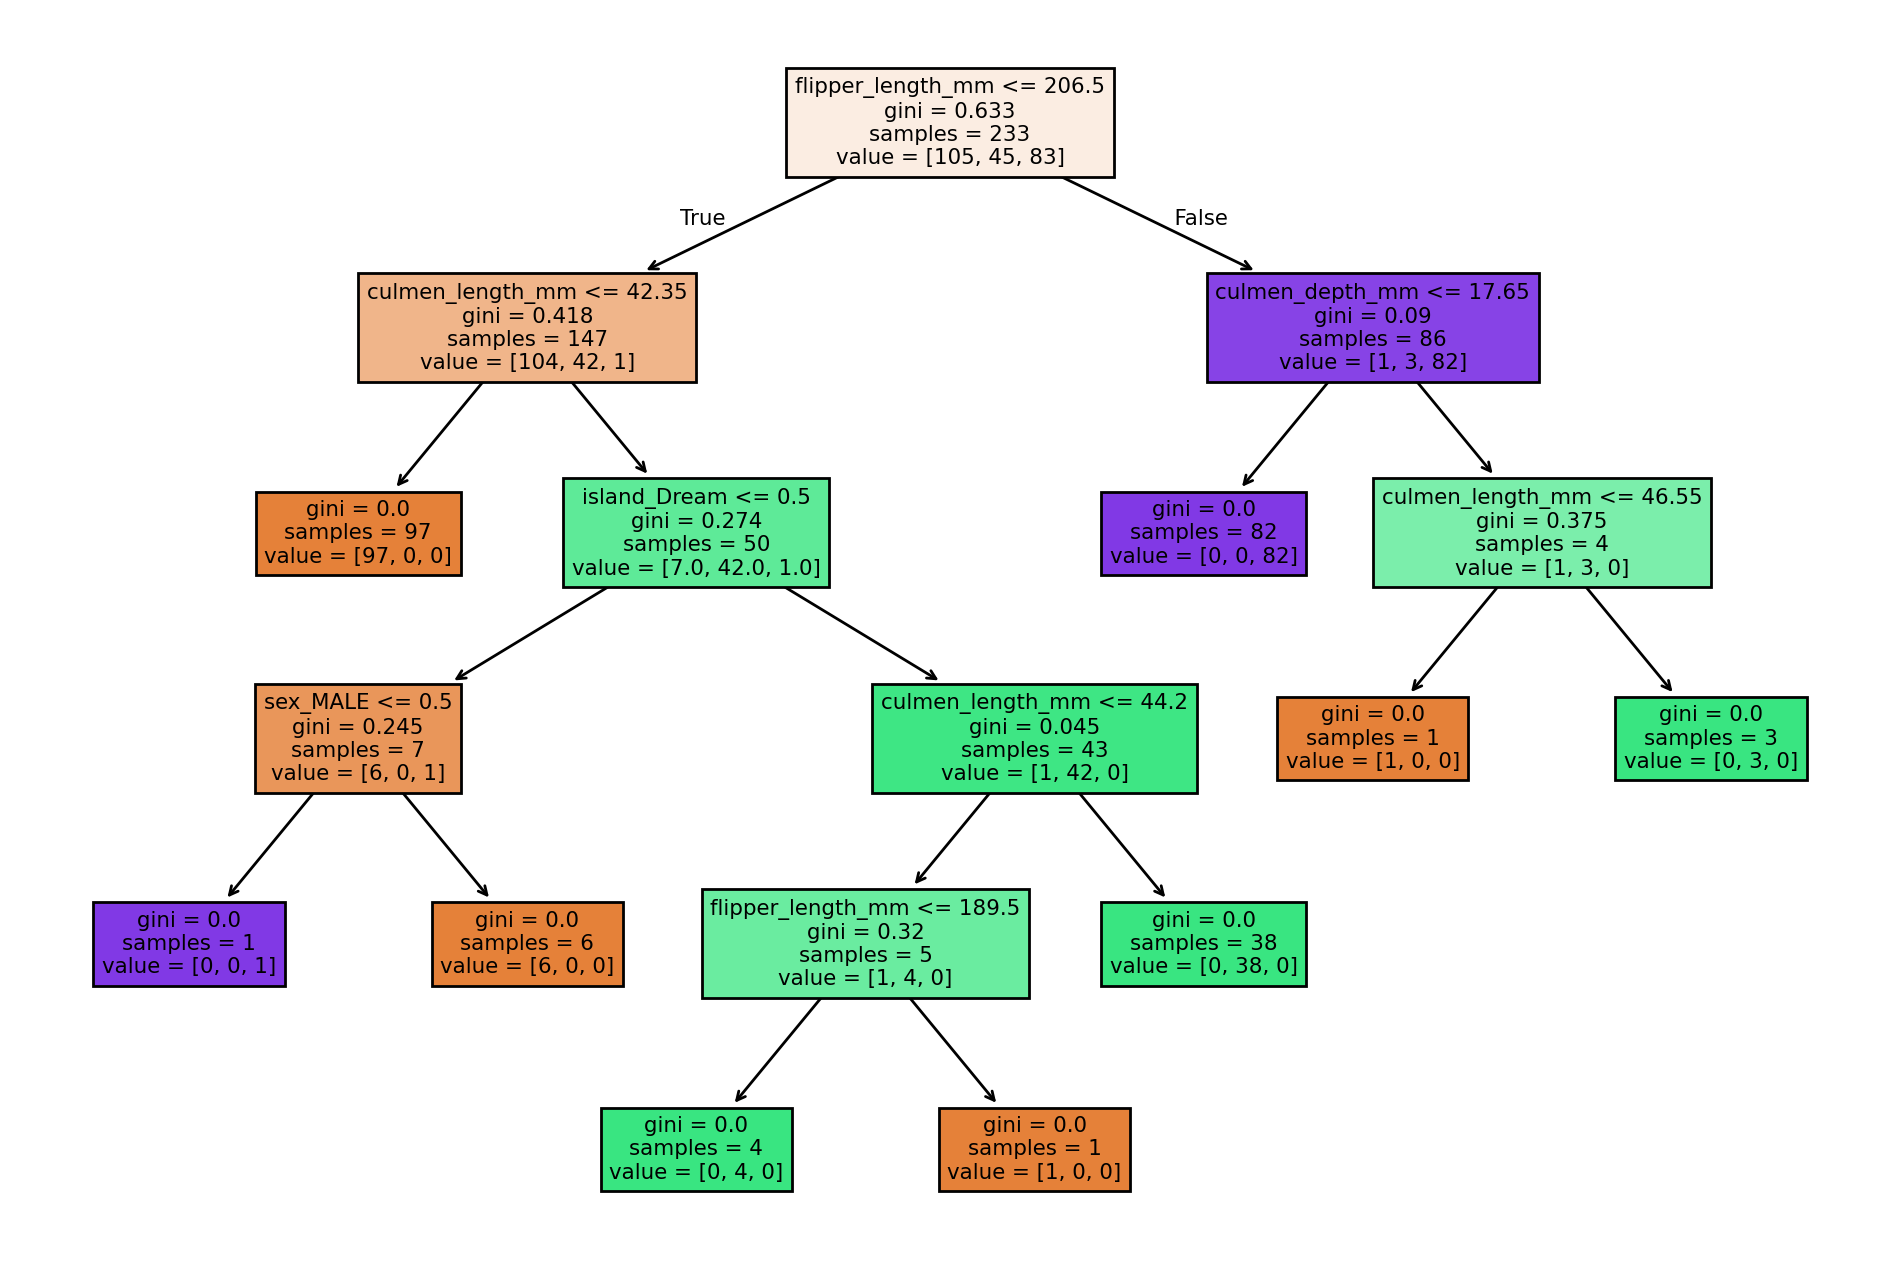

In [45]:
report_model(model)

Now we are going to explore the main hyperparameters available for the decision tree.

In [46]:
pruned_tree=DecisionTreeClassifier(max_depth=2)

In [47]:
pruned_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

      Adelie       0.97      0.88      0.92        41
   Chinstrap       0.81      0.96      0.88        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.94       101
   macro avg       0.93      0.94      0.93       101
weighted avg       0.95      0.94      0.94       101





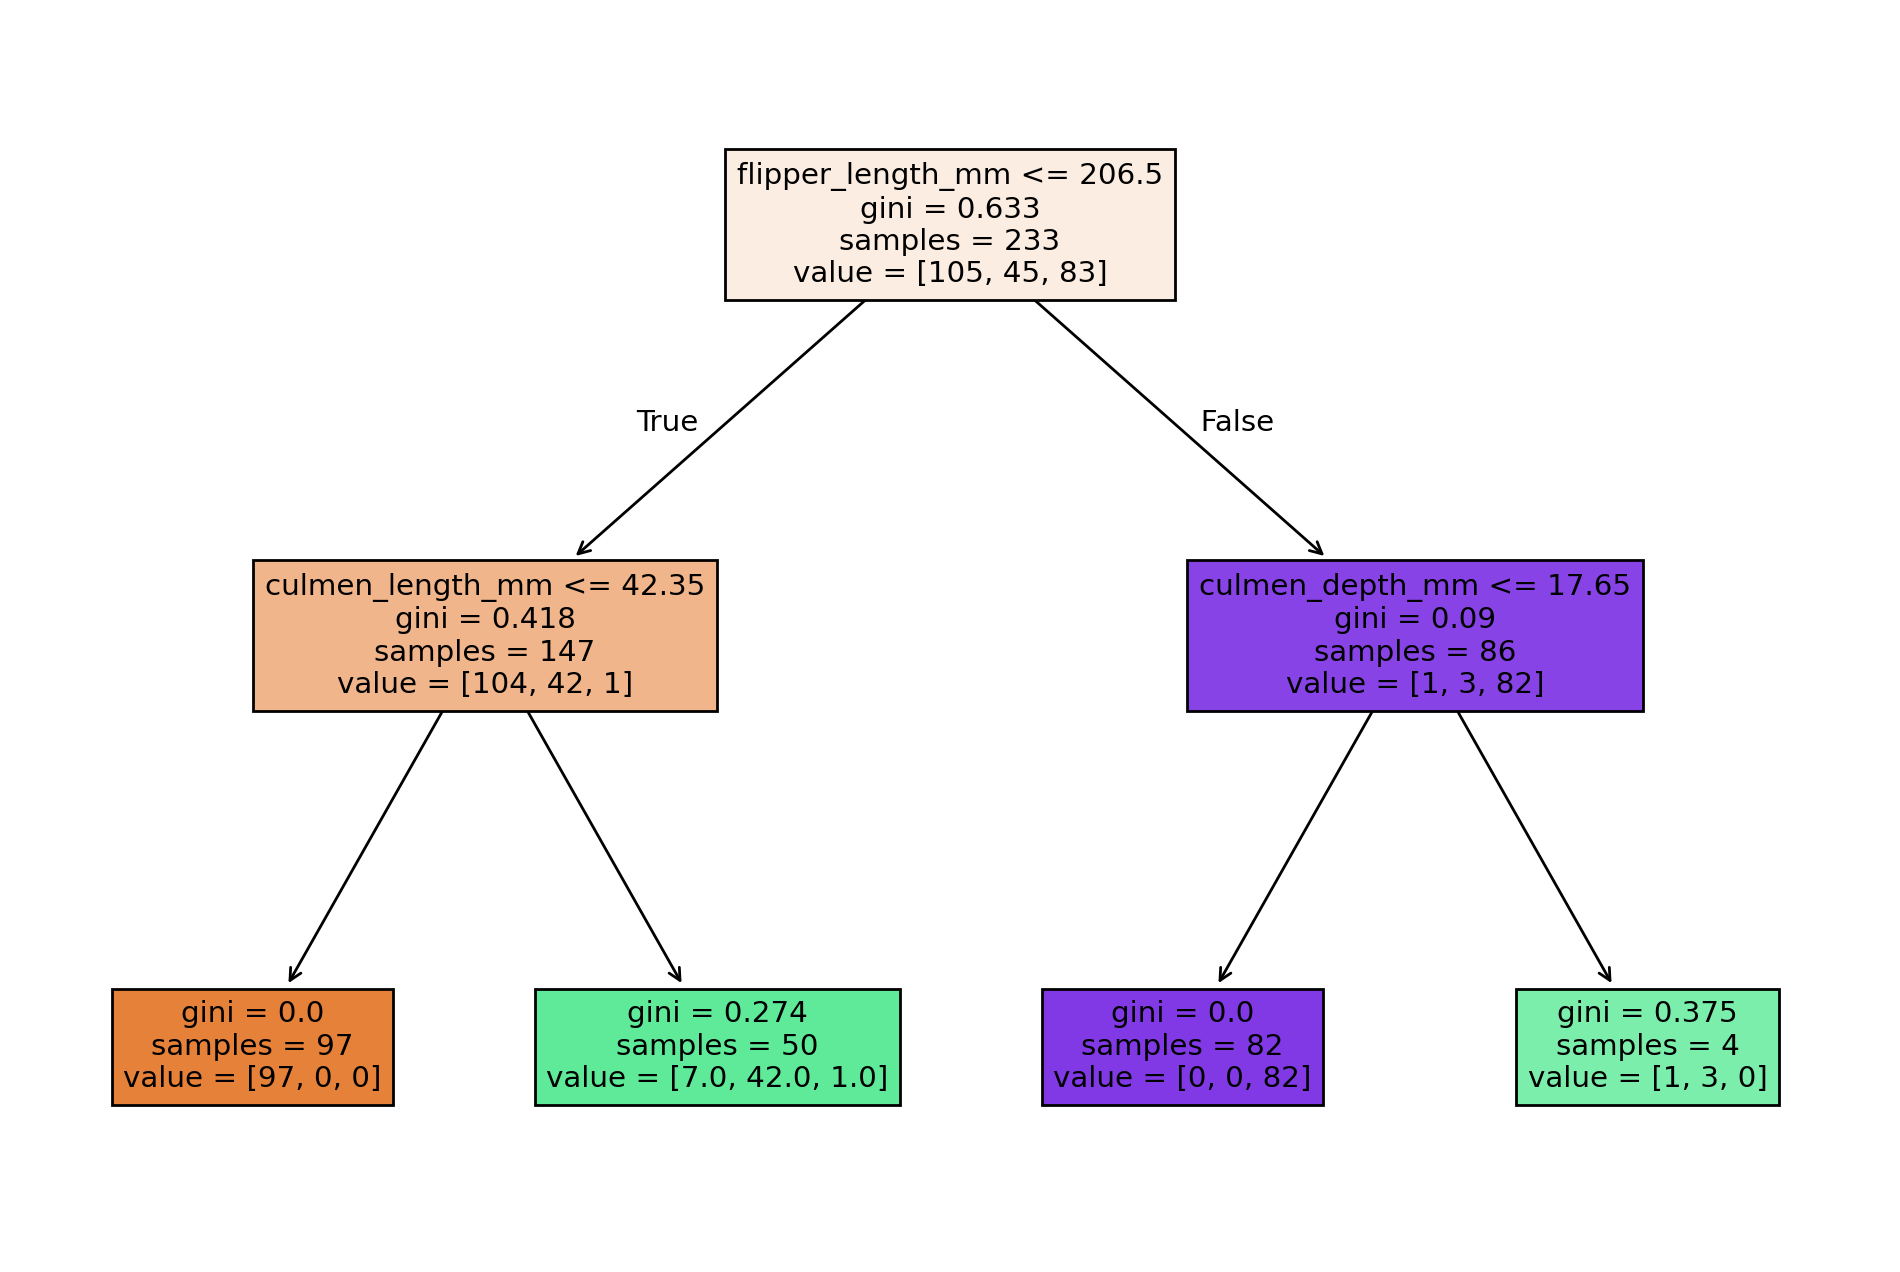

In [48]:
report_model(pruned_tree)

With less branches, it has a lowered performance. It now has a maximum of 2 levels of splits. This alows preventing overfit.

In [49]:
max_leaf_tree = DecisionTreeClassifier(max_leaf_nodes=3)

In [50]:
max_leaf_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,3
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

      Adelie       0.97      0.88      0.92        41
   Chinstrap       0.83      0.87      0.85        23
      Gentoo       0.93      1.00      0.96        37

    accuracy                           0.92       101
   macro avg       0.91      0.92      0.91       101
weighted avg       0.92      0.92      0.92       101





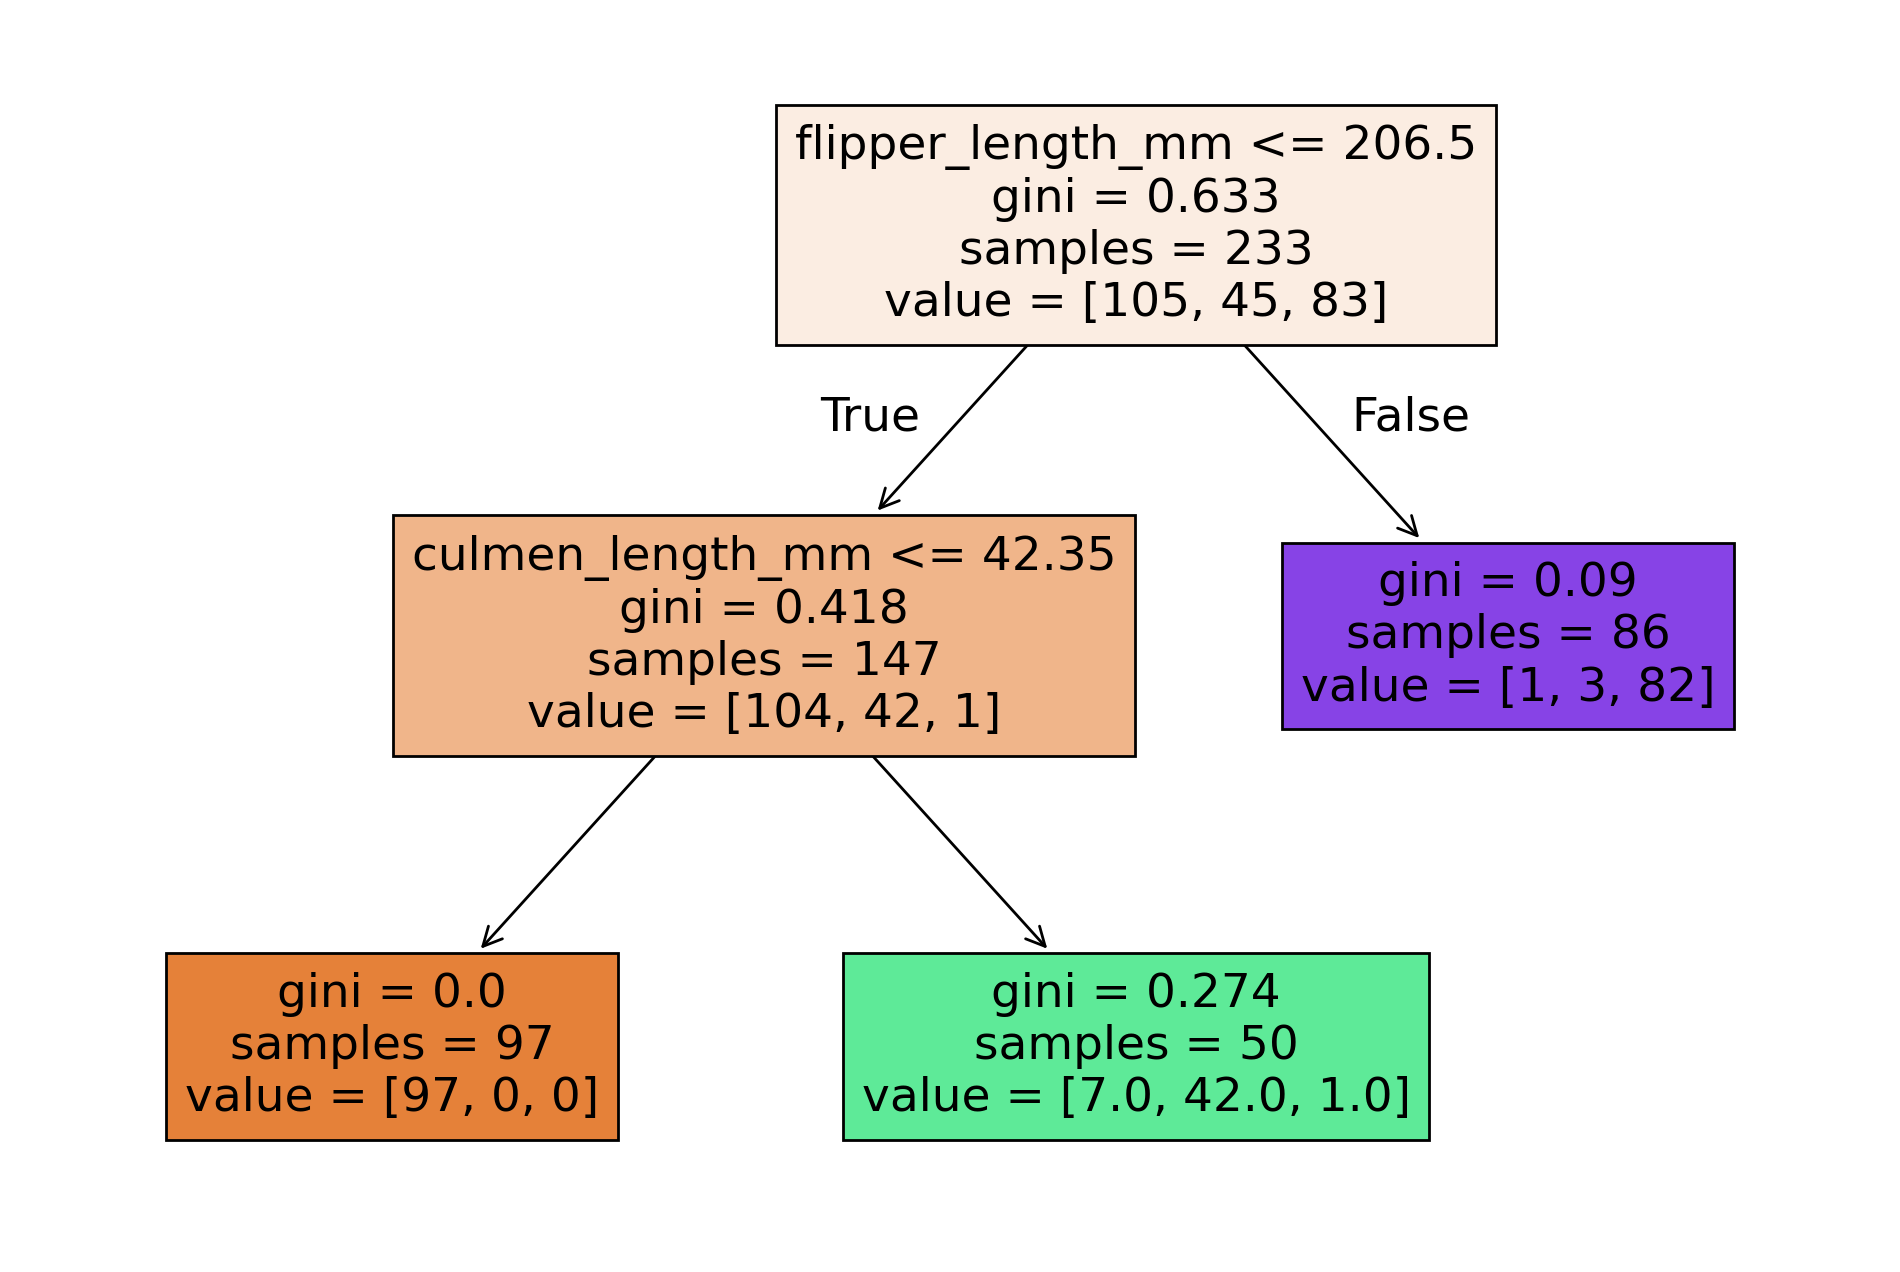

In [51]:
report_model(max_leaf_tree)

In [52]:
entropy_tree=DecisionTreeClassifier(criterion='entropy')

In [53]:
entropy_tree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

      Adelie       0.95      0.98      0.96        41
   Chinstrap       0.95      0.91      0.93        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       101
   macro avg       0.97      0.96      0.97       101
weighted avg       0.97      0.97      0.97       101





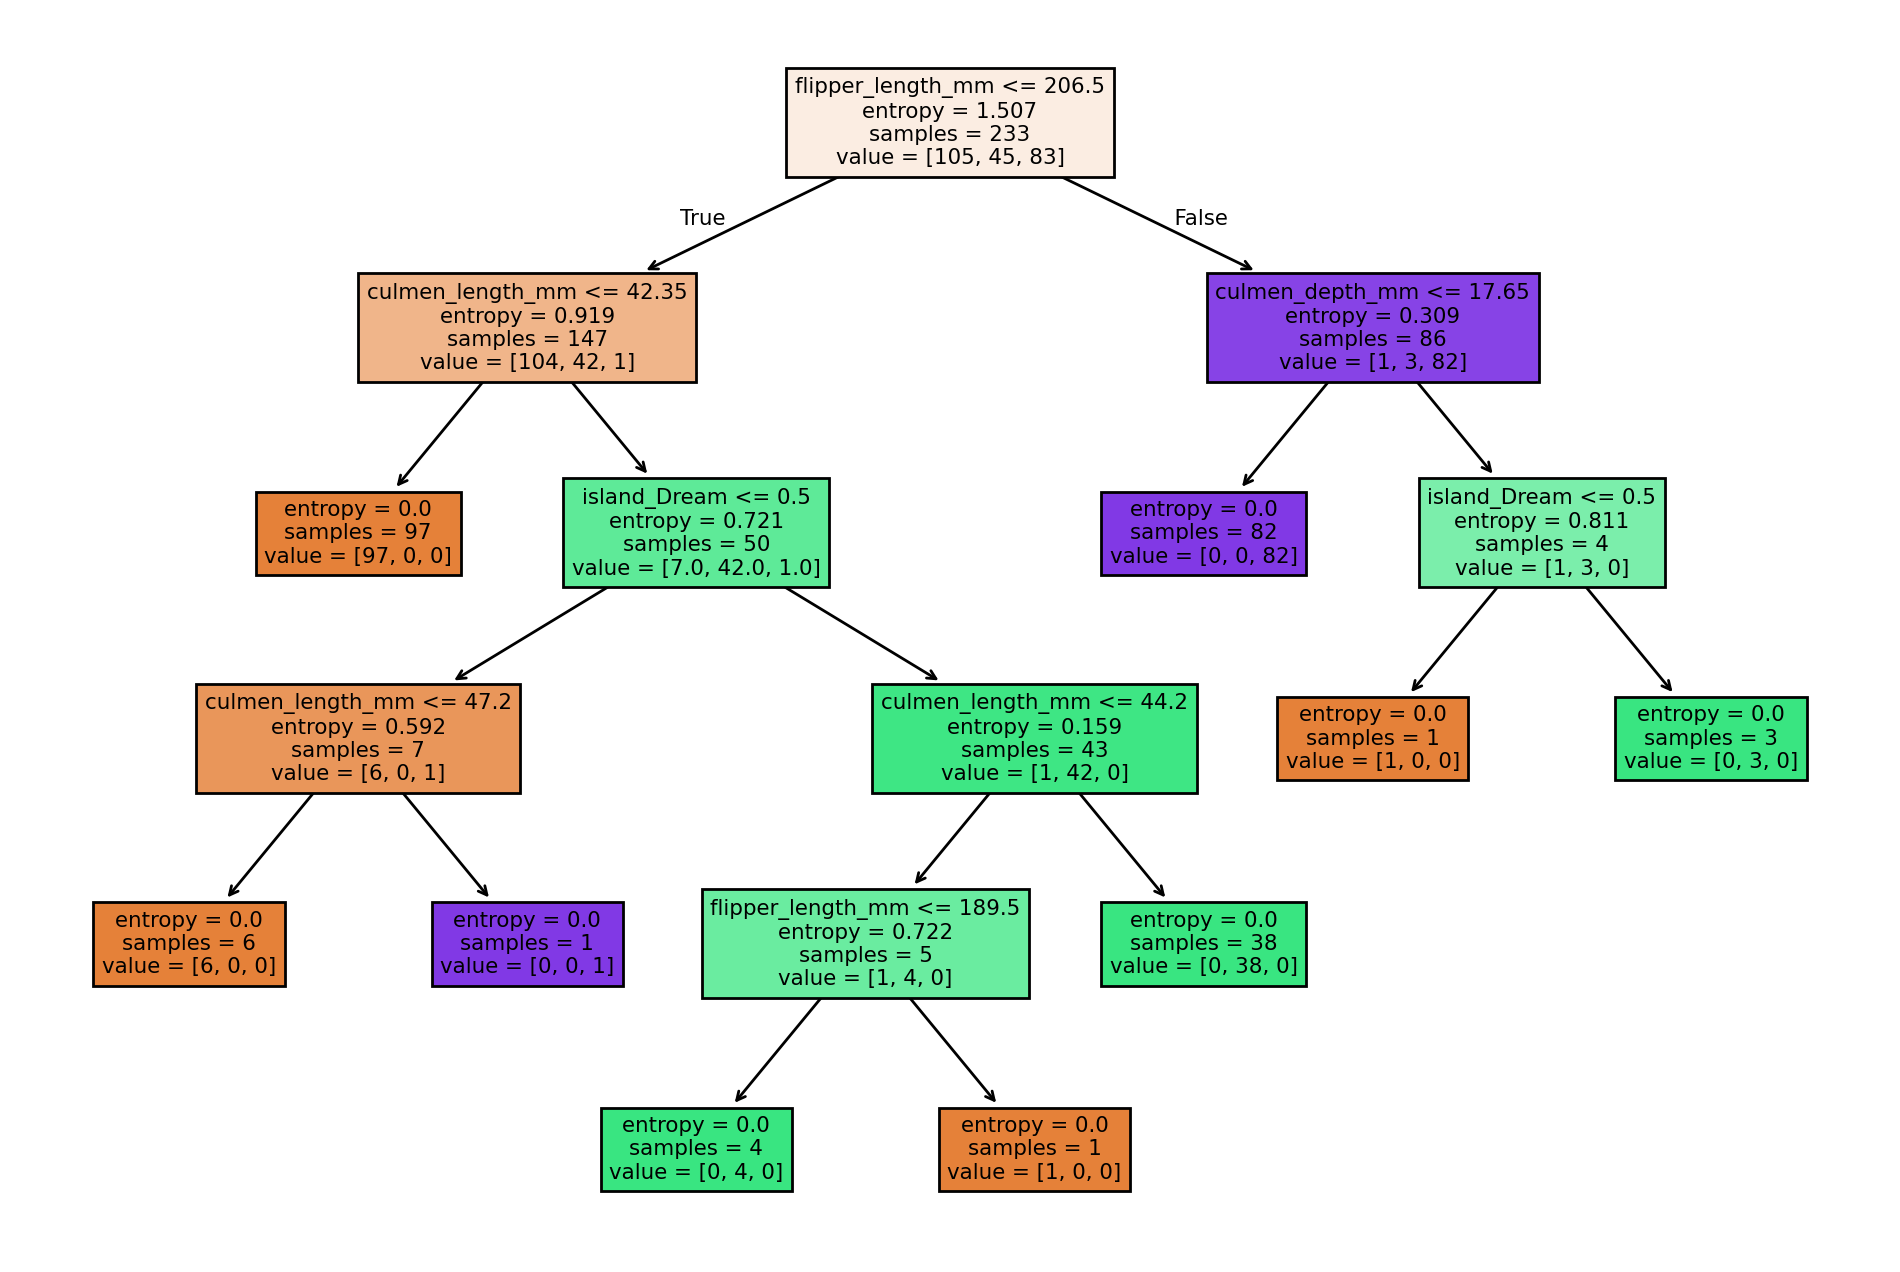

In [54]:
report_model(entropy_tree)

## Use GridSearch with the decision tree
There is probably not much to gain, since only 3 penguins are missclassified, but just for the sake of the exercise.

In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
mdl=DecisionTreeClassifier()
param_grid={'criterion':['gini','entropy','log_loss'],'splitter':['best','random'],'max_depth':[2,4,5,6,8,10],'min_samples_split':[2,4,7,10],'min_samples_leaf':[1,2,3],'max_features':[1,3,6]}

In [57]:
grid=GridSearchCV(mdl,param_grid,verbose=2)

In [58]:
grid.fit(X_train,y_train)
grid.best_params_

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END criterion=gini, max

{'criterion': 'gini',
 'max_depth': 4,
 'max_features': 6,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'best'}

### best params

So, the best params for this data set are:

{'criterion': 'gini',
 'max_depth': 4,
 'max_features': 6,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'best'}

 Let's see how they perform compared to the default, attempted at the beginning.

              precision    recall  f1-score   support

      Adelie       0.97      0.95      0.96        41
   Chinstrap       0.92      0.96      0.94        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       101
   macro avg       0.96      0.97      0.97       101
weighted avg       0.97      0.97      0.97       101





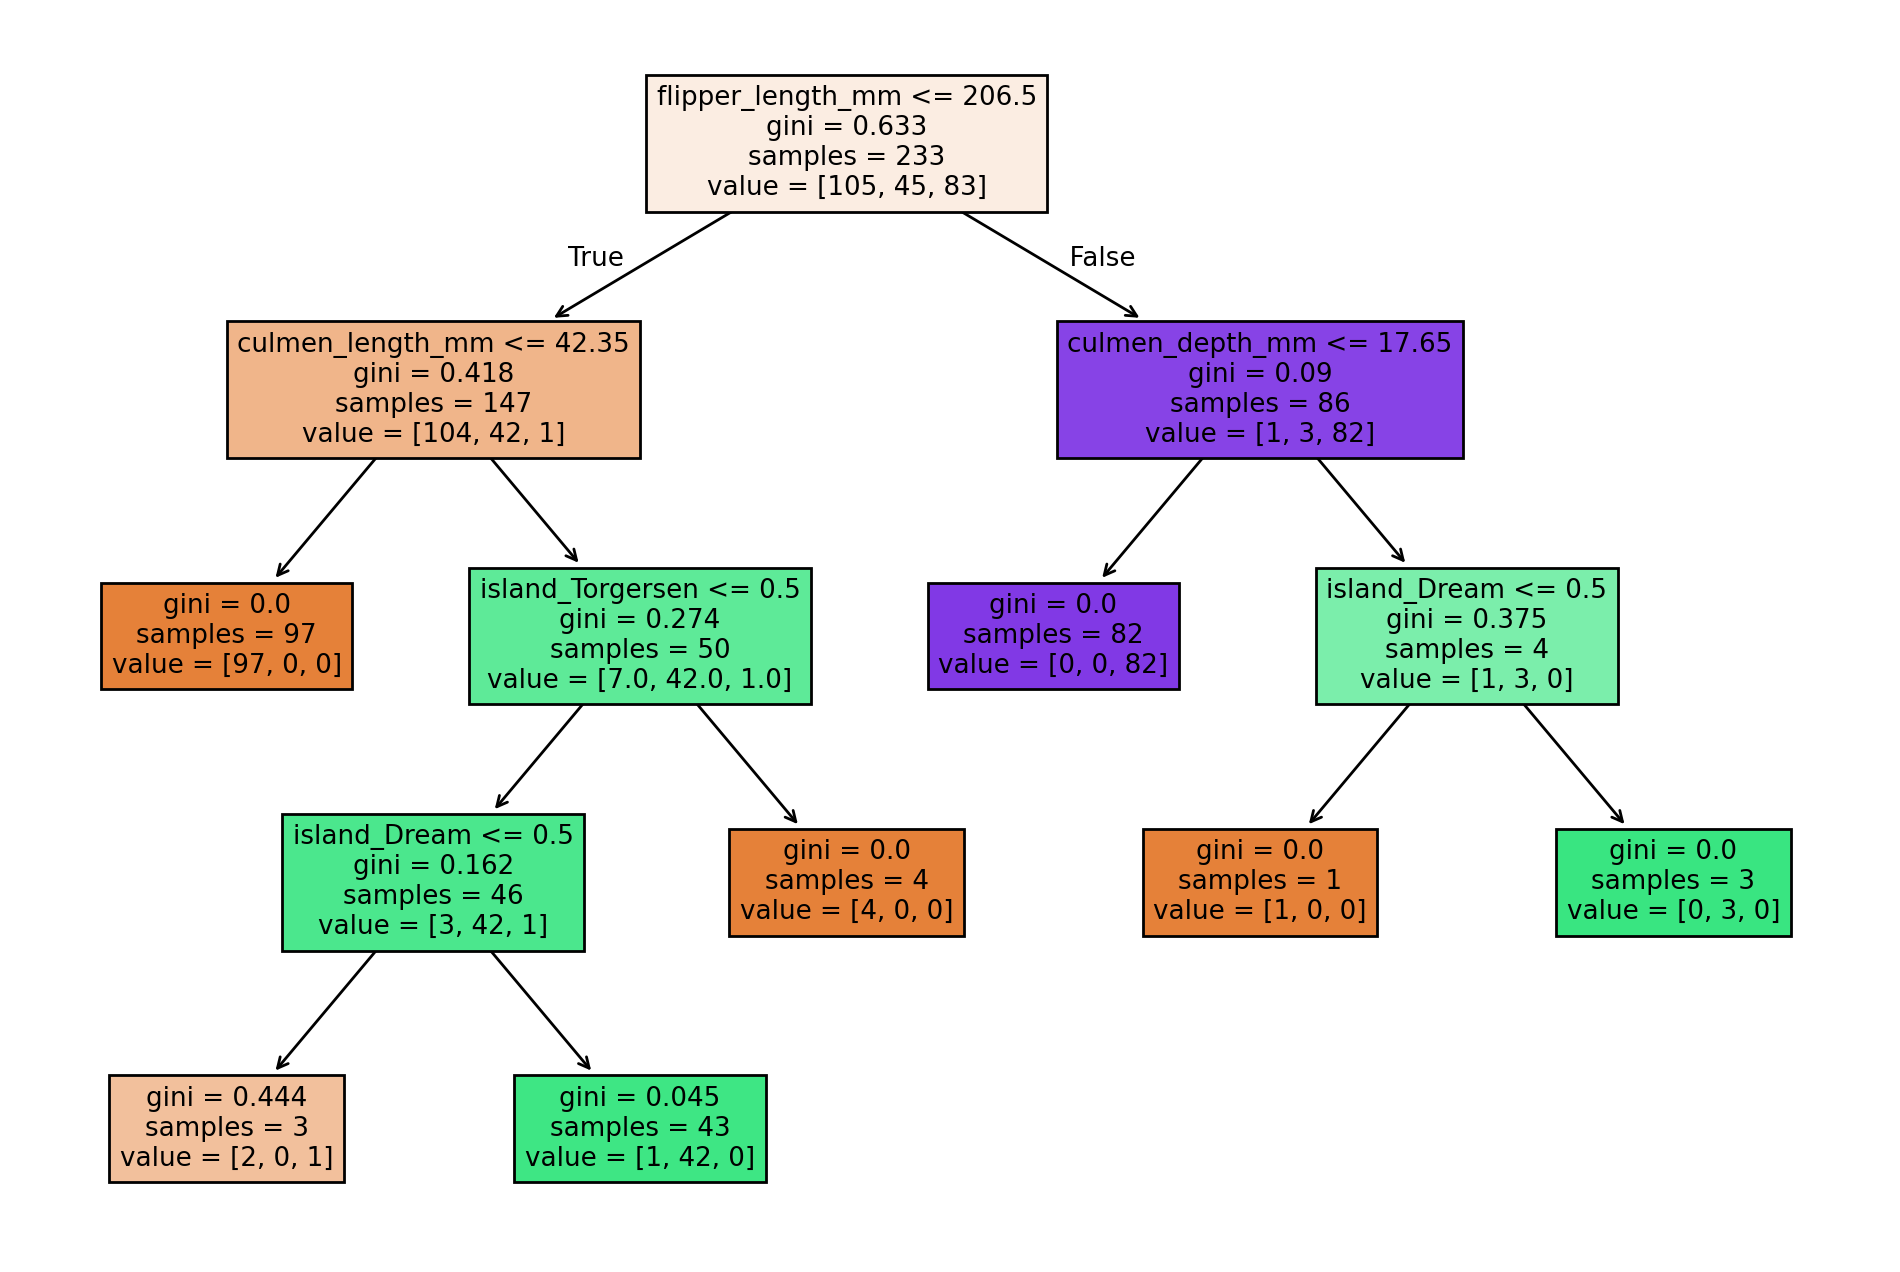

In [60]:
report_model(grid.best_estimator_)

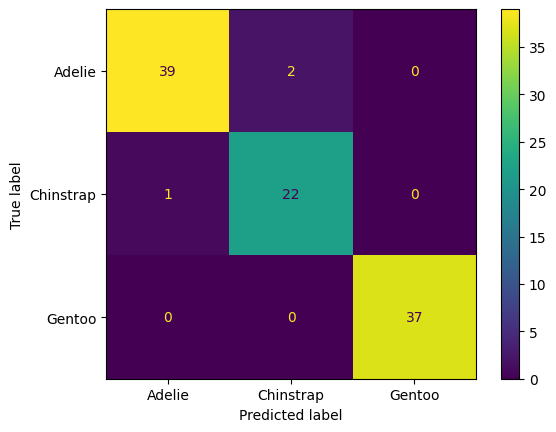

In [61]:
ConfusionMatrixDisplay.from_estimator(grid.best_estimator_, X_test,y_test)

We've still got three penguins misclassified.